<a href="https://colab.research.google.com/github/senBenz/ML/blob/main/TP_ML_4_Mini_Projets_Complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP Machine Learning — 4 Mini-Projets

Ce notebook contient :
1. KNN — Clients Premium
2. Arbre de Décision — Réussite Étudiants
3. Naive Bayes — Spam Email
4. SVM — Classification Fruits


# 🧠 Mini-Projet 1 — KNN : Clients Premium

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd

path = "/content/drive/MyDrive/mini_projet_1_clients.csv"
df = pd.read_csv(path)

df.head()

,Age,Revenu,Frequence_Achat,Ville,Premium
0,58,2706.0,3,Rabat,0
1,48,7634.0,7,Fes,0
2,34,8477.0,3,Fes,0
3,27,10221.0,4,Marrakech,0
4,40,9535.0,7,Rabat,1


✅ Meilleur K = 1 | Accuracy(test) = 0.8333


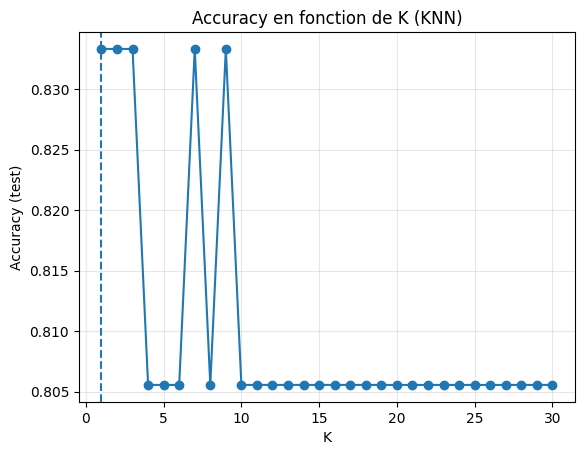


📌 Accuracy finale: 0.8333333333333334


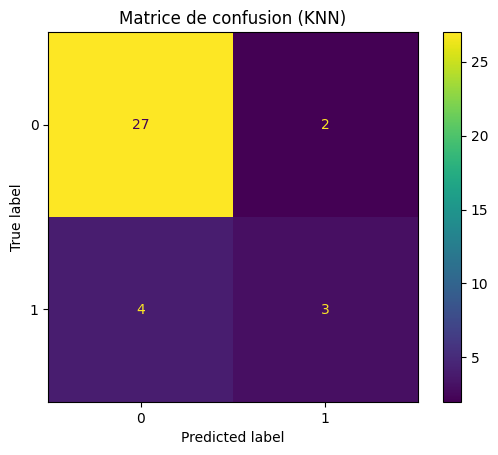


📌 Classification report :

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.60      0.43      0.50         7

    accuracy                           0.83        36
   macro avg       0.74      0.68      0.70        36
weighted avg       0.82      0.83      0.82        36



<Figure size 640x480 with 0 Axes>

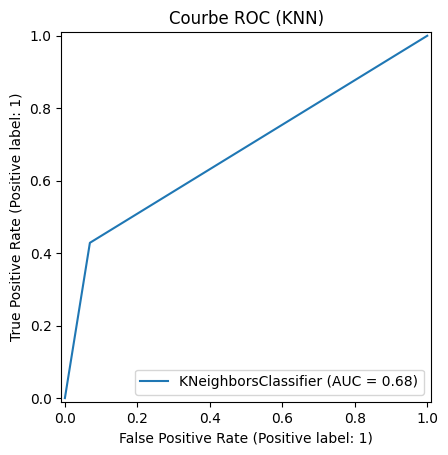

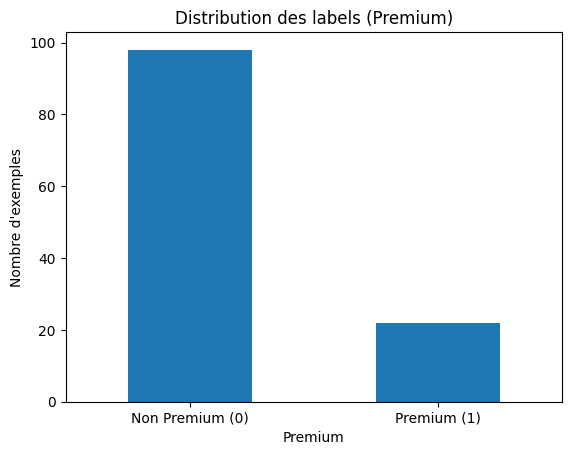

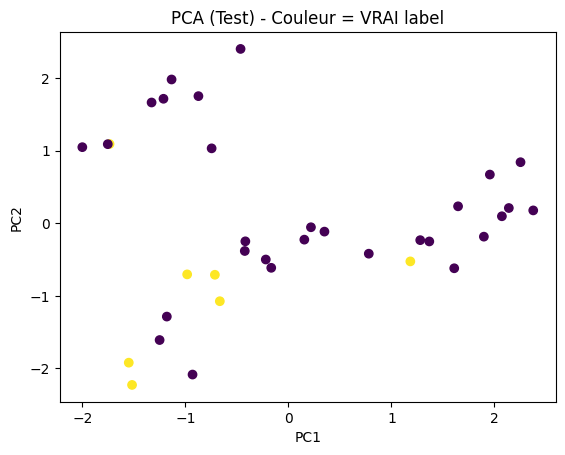

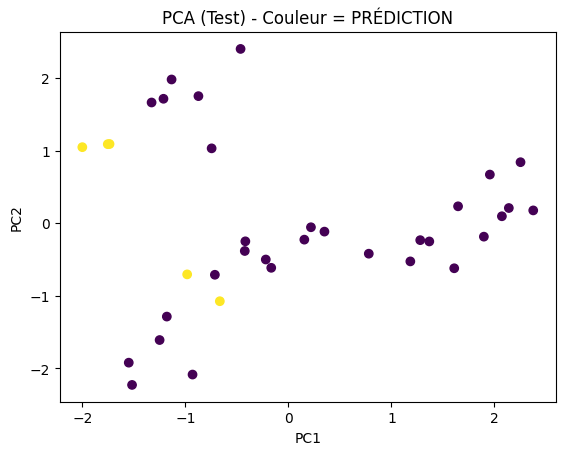

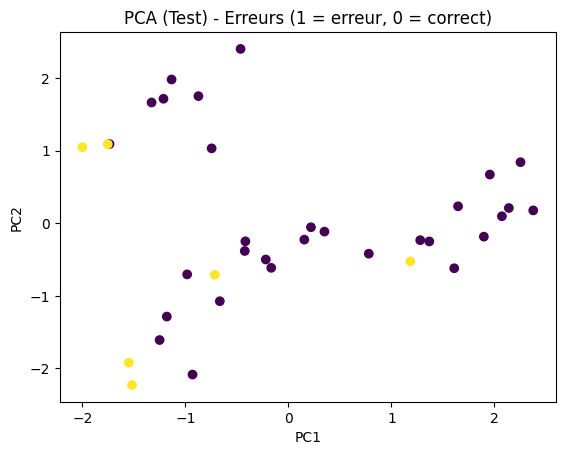

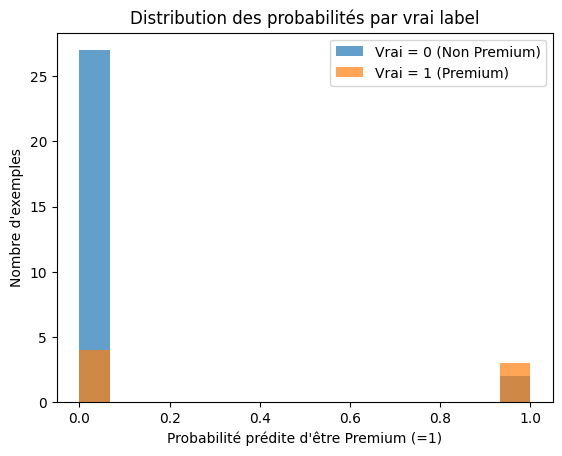

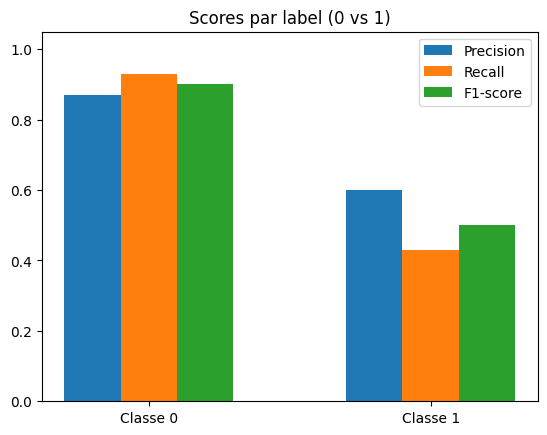

In [16]:
import pandas as pd

path = "/content/drive/MyDrive/mini_projet_1_clients.csv"
data = pd.read_csv(path)




# =========================
# KNN complet (préparation + choix K + évaluation + plots par labels)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay, precision_recall_fscore_support
)
from sklearn.decomposition import PCA

# =========================
# 1) Chargement + Préparation
# =========================
data = pd.read_csv(path)

# Imputation simple
data["Revenu"] = data["Revenu"].fillna(data["Revenu"].mean())

# One-hot encoding
data = pd.get_dummies(data, columns=["Ville"], drop_first=True)

# Séparation X / y
X = data.drop("Premium", axis=1)
y = data["Premium"]

# Split train/test (stratify pour garder les proportions 0/1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardisation (IMPORTANT pour KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 2) Choix de K (Accuracy vs K)
# =========================
k_values = range(1, 31)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_tmp = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_tmp))

best_k = list(k_values)[int(np.argmax(accuracies))]
best_acc = max(accuracies)

print(f"✅ Meilleur K = {best_k} | Accuracy(test) = {best_acc:.4f}")

plt.figure()
plt.plot(list(k_values), accuracies, marker="o")
plt.axvline(best_k, linestyle="--")
plt.xlabel("K")
plt.ylabel("Accuracy (test)")
plt.title("Accuracy en fonction de K (KNN)")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
# 3) Modèle final avec best_k
# =========================
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

acc_final = accuracy_score(y_test, y_pred)
print("\n📌 Accuracy finale:", acc_final)

# =========================
# 4) Matrice de confusion
# =========================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matrice de confusion (KNN)")
plt.show()

# =========================
# 5) Classification report
# =========================
print("\n📌 Classification report :\n")
print(classification_report(y_test, y_pred))

# =========================
# 6) Courbe ROC
# =========================
plt.figure()
RocCurveDisplay.from_estimator(final_model, X_test_scaled, y_test)
plt.title("Courbe ROC (KNN)")
plt.show()



# =========================
# 7) Plots PAR LABELS (0 vs 1)
# =========================

# A) Répartition des classes
plt.figure()
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Non Premium (0)", "Premium (1)"], rotation=0)
plt.ylabel("Nombre d'exemples")
plt.title("Distribution des labels (Premium)")
plt.show()

# B) PCA 2D - Couleur = vrai label
pca = PCA(n_components=2)
X_test_2d = pca.fit_transform(X_test_scaled)

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (Test) - Couleur = VRAI label")
plt.show()

# C) PCA 2D - Couleur = prédiction
plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_pred)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (Test) - Couleur = PRÉDICTION")
plt.show()

# D) PCA - afficher seulement les erreurs (y_pred != y_test)
errors = (y_pred != y_test.to_numpy())

plt.figure()
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=errors.astype(int))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (Test) - Erreurs (1 = erreur, 0 = correct)")
plt.show()

# E) Histogramme des probabilités par vrai label
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

plt.figure()
plt.hist(y_proba[y_test == 0], bins=15, alpha=0.7, label="Vrai = 0 (Non Premium)")
plt.hist(y_proba[y_test == 1], bins=15, alpha=0.7, label="Vrai = 1 (Premium)")
plt.xlabel("Probabilité prédite d'être Premium (=1)")
plt.ylabel("Nombre d'exemples")
plt.title("Distribution des probabilités par vrai label")
plt.legend()
plt.show()

# F) Precision / Recall / F1 par classe (plot)
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1])

plt.figure()
x = np.arange(2)
plt.bar(x - 0.2, prec, width=0.2, label="Precision")
plt.bar(x,       rec,  width=0.2, label="Recall")
plt.bar(x + 0.2, f1,   width=0.2, label="F1-score")
plt.xticks(x, ["Classe 0", "Classe 1"])
plt.ylim(0, 1.05)
plt.title("Scores par label (0 vs 1)")
plt.legend()
plt.show()


 Accuracy finale: 0.8333333333333334

  Mean Squared Error (MSE): 0.16666666666666666


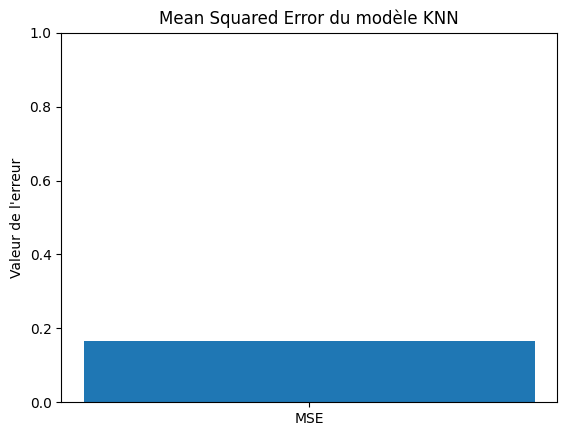

In [18]:
y_pred = final_model.predict(X_test_scaled)

acc_final = accuracy_score(y_test, y_pred)
print("\n Accuracy finale:", acc_final)

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("\n  Mean Squared Error (MSE):", mse)


plt.figure()
plt.bar(["MSE"], [mse])
plt.ylabel("Valeur de l'erreur")
plt.title("Mean Squared Error du modèle KNN")
plt.ylim(0, 1)
plt.show()

# 🌳 Mini-Projet 2 — Arbre de Décision : Réussite Étudiants

In [ ]:
# =========================
# MINI-PROJET 2 — Arbre de Décision (Réussite Étudiants)
# Code complet : choix de max_depth + entraînement + évaluation + plots + affichage de l'arbre
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay, precision_recall_fscore_support
)

# =========================
# 1) Chargement des données
# =========================
data = pd.read_csv("mini_projet_2_etudiants.csv")

# Séparation X / y
X = data.drop("Resultat", axis=1)
y = data["Resultat"]

# Split train/test (stratify pour garder les proportions de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# 2) Choix de la profondeur (max_depth) : approche "scientifique"
#    -> on teste plusieurs profondeurs et on observe train vs test + CV
# =========================
depths = range(1, 21)

train_acc = []
test_acc = []
cv_acc = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    # Accuracy sur train et test
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

    # Accuracy moyenne en validation croisée (plus robuste)
    cv_acc.append(cross_val_score(clf, X_train, y_train, cv=5).mean())

# Meilleure profondeur selon la validation croisée (recommandé)
best_depth = list(depths)[int(np.argmax(cv_acc))]
print(f"✅ Meilleur max_depth (selon CV) = {best_depth} | CV Accuracy = {max(cv_acc):.4f}")

# Plot : train/test accuracy vs depth
plt.figure()
plt.plot(list(depths), train_acc, marker="o", label="Train")
plt.plot(list(depths), test_acc, marker="o", label="Test")
plt.plot(list(depths), cv_acc, marker="o", label="CV (train, 5-fold)")
plt.axvline(best_depth, linestyle="--", label=f"best_depth={best_depth}")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy en fonction de max_depth (Arbre de décision)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =========================
# 3) Modèle final avec best_depth
# =========================
model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n📌 Accuracy finale (test):", accuracy_score(y_test, y_pred))
print("📌 Profondeur réelle de l'arbre:", model.get_depth())
print("📌 Nombre de feuilles:", model.get_n_leaves())

# =========================
# 4) Matrice de confusion
# =========================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matrice de confusion (Arbre de décision)")
plt.show()

# =========================
# 5) Classification report
# =========================
print("\n📌 Classification report :\n")
print(classification_report(y_test, y_pred))

# =========================
# 6) ROC Curve (si classification binaire 0/1)
# =========================
# Si y est binaire, DecisionTreeClassifier supporte predict_proba => ROC possible
try:
    plt.figure()
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title("Courbe ROC (Arbre de décision)")
    plt.show()
except Exception as e:
    print("⚠️ ROC non disponible (probablement multi-classes). Détail:", e)

# =========================
# 7) Plot scores par classe : Precision / Recall / F1
# =========================
labels = sorted(y.unique())
prec, rec, f1, sup = precision_recall_fscore_support(y_test, y_pred, labels=labels, zero_division=0)

plt.figure()
x = np.arange(len(labels))
plt.bar(x - 0.2, prec, width=0.2, label="Precision")
plt.bar(x,       rec,  width=0.2, label="Recall")
plt.bar(x + 0.2, f1,   width=0.2, label="F1-score")
plt.xticks(x, [f"Classe {lab}" for lab in labels])
plt.ylim(0, 1.05)
plt.title("Scores par classe (Arbre de décision)")
plt.legend()
plt.show()

# =========================
# 8) Importance des variables
# =========================
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
plt.figure()
importances.plot(kind="barh")
plt.title("Importance des variables (Arbre de décision)")
plt.xlabel("Importance")
plt.show()

# =========================
# 9) Visualisation de l'arbre
# =========================
plt.figure(figsize=(14, 9))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=[str(c) for c in labels],
    filled=True,
    rounded=True
)
plt.title("Arbre de décision appris")
plt.show()

# =========================
# 10) Learning Curve (option très pédagogique)
# =========================
# Permet de voir surapprentissage / sous-apprentissage selon la taille de données
train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation (CV)")
plt.xlabel("Taille du dataset")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Arbre de décision)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 📧 Mini-Projet 3 — Naive Bayes : Spam Email

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

data = pd.read_csv('mini_projet_3_spam.csv')

X_text = data['Email']
y = data['Label']

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Accuracy Naive Bayes:', accuracy_score(y_test, y_pred))

# 🧮 Mini-Projet 4 — SVM : Classification Fruits

In [ ]:
from sklearn.svm import SVC

data = pd.read_csv('mini_projet_4_fruits.csv')

X = data.drop('Type', axis=1)
y = data['Type']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Accuracy SVM:', accuracy_score(y_test, y_pred))